In [508]:
from sklearn.datasets        import make_multilabel_classification
from sklearn.metrics         import classification_report
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch.nn.functional as F
import torch.nn as nn
import torch

from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import torch

In [509]:
X, y = make_multilabel_classification(n_samples=500, n_features=600, n_classes=3,n_labels=2, random_state=42)

# plt.figure(figsize=(5,5))
# plt.scatter(x = X[:,0], y = X[:,1], c = y[:,0])
# plt.show()
# plt.scatter(x = X[:,0], y = X[:,1], c = y[:,1])
# plt.show()
# plt.scatter(x = X[:,0], y = X[:,1], c = y[:,2])
# plt.show()

X = X.reshape(500,1,20,30)

[0 0 1]


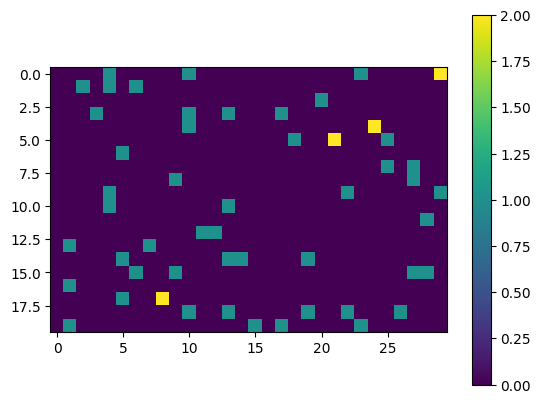

In [510]:
plt.imshow(X[3].reshape(20,30))
print(y[3])
plt.colorbar()
plt.show()

In [511]:
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size = 0.2,random_state = 42) 

X_train = torch.from_numpy(X_train).type(torch.float32)
Y_train = torch.from_numpy(Y_train).type(torch.float32)

X_test  = torch.from_numpy(X_test) .type(torch.float32)
Y_test  = torch.from_numpy(Y_test) .type(torch.float32)

training_dataset = TensorDataset(X_train,Y_train)
testing_dataset  = TensorDataset(X_test ,Y_test )

train_loader = DataLoader(TensorDataset(X_train,Y_train) , batch_size = X_train.shape[0], shuffle = False)
test_loader  = DataLoader(TensorDataset(X_test ,Y_test ) , batch_size = X_test.shape[0] , shuffle = False)

In [512]:
def train_model(model,device, optimizer ,data_loader, loss_module, num_epochs=100):
    model.train()
    train_losses  = []
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:
            # Put training data into GPU
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)
            preds = model(data_inputs).to(device)
            loss  = loss_module(preds, data_labels)
            train_losses.append(loss)

            # Zero the gradients
            optimizer.zero_grad()
            loss     .backward()
            optimizer.step()

    return train_losses

In [513]:
@torch.no_grad()
def eval_model(model, device, data_loader, target_names = False):
    model.eval()
    all_pred   = torch.empty((0,), dtype = torch.float32).to(device)
    all_labels = torch.empty((0,), dtype = torch.float32).to(device)

    for data_inputs, data_labels in data_loader:
        data_inputs = data_inputs.to(device)
        data_labels = data_labels.to(device)
        preds = model(data_inputs)
        pred_labels = (preds >= 0.5).long()
        all_pred   = torch.cat((all_pred,pred_labels), dim = 0 )
        all_labels = torch.cat((all_labels,data_labels))
    print(classification_report(y_pred =   all_pred.cpu().numpy(), y_true = all_labels.cpu().numpy(),  target_names  = target_names, zero_division = 0))

In [514]:
# model = nn.Sequential(
#     nn.Linear(in_features=4,out_features=20),
#     nn.ReLU(),
#     nn.Linear(in_features=20,out_features=3),
#     nn.Sigmoid()
# )
class Net(nn.Module):
    def __init__(self,embed_size):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels  = 1, out_channels = 1, kernel_size  = 5, padding      = 'same')
        self.attn = nn.MultiheadAttention(embed_dim=embed_size,num_heads=1)
        self.fc   = nn.Linear(600,3)

        #self.fc1   = nn.Linear(600, 300)
        #self.fc2   = nn.Linear(300, 3)
        self.Drop_layers = nn.Dropout(p = 0.5)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        #x = self.MaxPool(x)
        #batch, channel, seq_len, embed = x.shape
        #x = x.reshape(batch,seq_len,embed)
        #x = self.attn(x,x,x,)[0] 
        x = torch.flatten(x,1)
        #x = torch.sum(torch.stack(r), dim=0) # Used when the output of each linear layer is three. 
        #x = torch.flatten(x, 1)
        #x = F.relu(self.fc1(x))
        #x = self.Drop_layers(x)
        #x = self.fc2(x)
        x = F.sigmoid(self.fc(x))
        return x

model = Net(embed_size = 30)
model.to(device=torch.device('cpu'))
model.conv1

loss_module = nn.BCELoss()
optimizer   = torch.optim.SGD(params=model.parameters(),lr = 0.1)


100%|██████████| 700/700 [00:14<00:00, 48.55it/s]


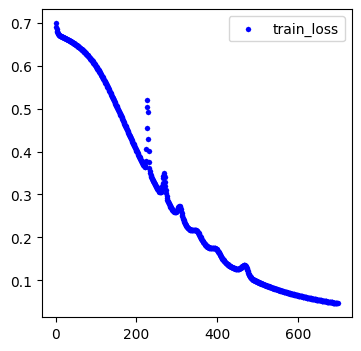

In [515]:
hist = train_model(model       = model,
                   device      = torch.device('cpu'),
                   optimizer   = optimizer,
                   data_loader = train_loader,
                   loss_module = loss_module,
                   num_epochs  = 700)

hist = [float(h.cpu().detach()) for h in hist]
plt.figure(figsize=(4,4))
plt.scatter(y = hist,
            x = [_ for _ in range(len(hist))],
            alpha = 1, lw = 0.1, c = 'b', s = 14, label = 'train_loss')
plt.legend()
plt.show()

In [517]:
eval_model(model = model,
           device= torch.device('cpu'),
           data_loader=train_loader,
           target_names=[f'Label {i}' for i in range(3)])

eval_model(model = model,
           device= torch.device('cpu'),
           data_loader=test_loader,
           target_names=[f'Label {i}' for i in range(3)])

              precision    recall  f1-score   support

     Label 0       1.00      1.00      1.00       159
     Label 1       1.00      1.00      1.00       248
     Label 2       1.00      1.00      1.00       215

   micro avg       1.00      1.00      1.00       622
   macro avg       1.00      1.00      1.00       622
weighted avg       1.00      1.00      1.00       622
 samples avg       0.84      0.84      0.84       622

              precision    recall  f1-score   support

     Label 0       0.59      0.70      0.64        37
     Label 1       0.68      0.68      0.68        56
     Label 2       0.72      0.81      0.76        53

   micro avg       0.67      0.73      0.70       146
   macro avg       0.66      0.73      0.69       146
weighted avg       0.67      0.73      0.70       146
 samples avg       0.65      0.66      0.62       146

